# Task 4 — Machine Learning Model Implementation
## Spam Email Detection using Scikit-learn

**Internship Deliverable:** Jupyter Notebook  
**Objective:** Build a text-classification model that predicts whether a message is **Spam** or **Ham (Not Spam)**.

### Workflow
1. Load and inspect the dataset
2. Clean the data
3. Explore class distribution
4. Split data into training and testing sets
5. Convert text into numerical features using TF-IDF
6. Train a Logistic Regression classifier
7. Evaluate the model
8. Test the model on new messages

> **Note:** The included dataset is a small educational dataset created for this internship demonstration. Real-world spam filtering requires a much larger and more diverse dataset.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

## 2. Load the Dataset

The dataset should contain a label column and a message/text column. The loader below supports the common column names `label` + `message`, and `label` + `text`.

In [3]:
# Load the dataset from the same folder as this notebook
df = pd.read_csv("spam_dataset.csv")

# Clean column names
df.columns = df.columns.astype(str).str.strip().str.lower()

# Standardize common text-column names
if "text" in df.columns and "message" not in df.columns:
    df = df.rename(columns={"text": "message"})

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset shape: (60, 2)
Columns: ['label', 'message']


,label,message
0,ham,"Hey, are we still meeting at 6 today?"
1,ham,Please send me the project report when you get...
2,ham,Your appointment is confirmed for tomorrow at ...
3,ham,Can you call me after class?
4,ham,Do not forget to bring your laptop for the mee...


## 3. Inspect the Dataset

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["label"].value_counts(dropna=False))

Missing values:
label      0
message    0
dtype: int64

Class distribution:
label
ham     30
spam    30
Name: count, dtype: int64


## 4. Data Cleaning

We remove missing records, standardize labels, and remove duplicate messages. The expected labels are `ham` and `spam`.

In [5]:
# Remove rows with missing label or message
df = df.dropna(subset=["label", "message"]).copy()

# Standardize text and labels
df["label"] = df["label"].astype(str).str.strip().str.lower()
df["message"] = df["message"].astype(str).str.strip()

# Support common numeric labels if they are present
df["label"] = df["label"].replace({"0": "ham", "1": "spam"})

# Keep only the two classes used by this project
df = df[df["label"].isin(["ham", "spam"])].copy()

# Remove duplicate messages
df = df.drop_duplicates(subset="message").reset_index(drop=True)

if df.empty:
    raise ValueError("The dataset is empty after cleaning. Check the label values in spam_dataset.csv.")

if df["label"].nunique() < 2:
    raise ValueError("The dataset must contain both ham and spam messages.")

print("Cleaned dataset shape:", df.shape)
print("\nCleaned class distribution:")
print(df["label"].value_counts())
df.head()

Cleaned dataset shape: (60, 2)

Cleaned class distribution:
label
ham     30
spam    30
Name: count, dtype: int64


,label,message
0,ham,"Hey, are we still meeting at 6 today?"
1,ham,Please send me the project report when you get...
2,ham,Your appointment is confirmed for tomorrow at ...
3,ham,Can you call me after class?
4,ham,Do not forget to bring your laptop for the mee...


## 5. Explore the Class Distribution

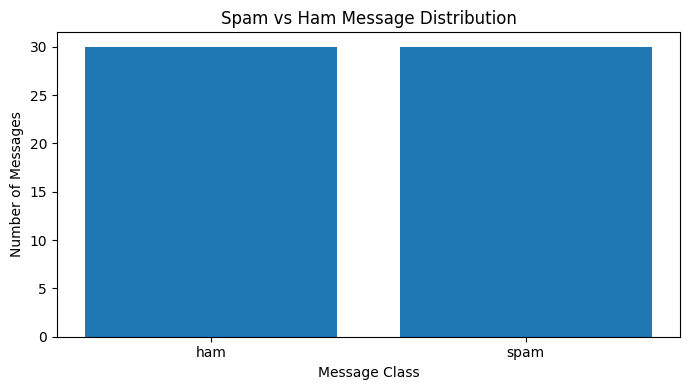

In [6]:
class_counts = df["label"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Spam vs Ham Message Distribution")
plt.xlabel("Message Class")
plt.ylabel("Number of Messages")
plt.tight_layout()
plt.show()

## 6. Prepare Features and Target

In [7]:
X = df["message"]
y = df["label"]

print("Number of messages:", len(X))
print("Target classes:", sorted(y.unique()))

Number of messages: 60
Target classes: ['ham', 'spam']


## 7. Split the Data into Training and Testing Sets

We use 80% of the data for training and 20% for testing. `stratify=y` preserves the class proportions in both sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 48
Testing samples: 12


## 8. Convert Text into TF-IDF Features

TF-IDF converts text into numerical features that can be used by a machine-learning classifier. We fit the vectorizer only on training data to avoid data leakage.

In [9]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (48, 287)
Testing TF-IDF shape: (12, 287)


## 9. Build and Train the Machine Learning Model

In [10]:
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the classifier
model.fit(X_train_tfidf, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## 10. Make Predictions

In [11]:
y_pred = model.predict(X_test_tfidf)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,ham,ham
1,spam,spam
2,spam,spam
3,ham,ham
4,spam,spam
5,ham,ham
6,spam,spam
7,ham,ham
8,spam,spam
9,ham,ham


## 11. Evaluate the Model

The evaluation uses accuracy, precision, recall, and F1-score. These metrics are calculated on the held-out test set.

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="spam", zero_division=0)
recall = recall_score(y_test, y_pred, pos_label="spam", zero_division=0)
f1 = f1_score(y_test, y_pred, pos_label="spam", zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics_df["Score"] = metrics_df["Score"].round(4)
metrics_df

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-Score,1.0


### Classification Report

In [13]:
print(classification_report(
    y_test, y_pred, target_names=["ham", "spam"], zero_division=0
))

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         6
        spam       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



## 12. Confusion Matrix

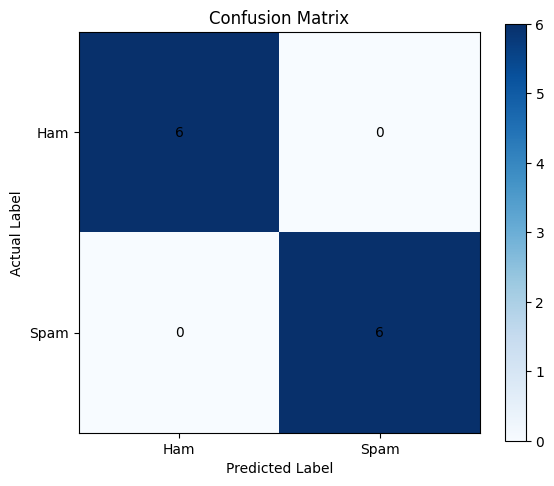

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_xticks([0, 1], ["Ham", "Spam"])
ax.set_yticks([0, 1], ["Ham", "Spam"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 13. Test the Model with New Messages

In [15]:
def predict_message(message):
    # Convert the new message using the fitted TF-IDF vectorizer
    message_tfidf = vectorizer.transform([message])

    # Predict the class
    prediction = model.predict(message_tfidf)[0]

    # Return class probabilities for additional context
    probabilities = model.predict_proba(message_tfidf)[0]
    class_probabilities = dict(zip(model.classes_, probabilities))

    return prediction, class_probabilities


test_messages = [
    "Please send me the meeting notes this evening.",
    "Congratulations! Claim your free prize now."
]

for message in test_messages:
    prediction, probabilities = predict_message(message)
    print("Message:", message)
    print("Prediction:", prediction.upper())
    print("Probabilities:", {k: round(v, 3) for k, v in probabilities.items()})
    print("-" * 60)

Message: Please send me the meeting notes this evening.
Prediction: HAM
Probabilities: {'ham': np.float64(0.626), 'spam': np.float64(0.374)}
------------------------------------------------------------
Message: Congratulations! Claim your free prize now.
Prediction: SPAM
Probabilities: {'ham': np.float64(0.31), 'spam': np.float64(0.69)}
------------------------------------------------------------


## 14. Scikit-learn Pipeline

A pipeline combines TF-IDF preprocessing and Logistic Regression into one reusable object.

In [16]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True, stop_words="english", ngram_range=(1, 2)
    )),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)
pipeline_predictions = pipeline.predict(X_test)
pipeline_accuracy = accuracy_score(y_test, pipeline_predictions)

print(f"Pipeline accuracy: {pipeline_accuracy:.4f}")

Pipeline accuracy: 1.0000


## 15. Conclusion

This project demonstrates an end-to-end machine-learning classification workflow using **Python, Pandas, TF-IDF, and Scikit-learn**.

### Key learning outcomes
- Loaded and inspected a text dataset
- Cleaned and prepared the data
- Explored class distribution
- Split data into training and testing sets
- Converted text into TF-IDF features
- Trained a Logistic Regression classifier
- Evaluated the model using multiple metrics
- Visualized the confusion matrix
- Tested the model on new messages

### Result
The notebook calculates the final evaluation metrics directly from the held-out test set. Because the included dataset is small and educational, these scores should not be treated as production-level performance.

**Task 4 — Machine Learning Model Implementation: Completed.**

## GitHub Submission Checklist

- [x] Jupyter Notebook
- [x] Dataset
- [x] Data preprocessing
- [x] TF-IDF feature extraction
- [x] Scikit-learn model
- [x] Model evaluation
- [x] Confusion matrix
- [x] New-message prediction
- [x] Comments and Markdown explanations
- [ ] Run **Restart Kernel → Run All** before submission
- [ ] Confirm all cells execute without errors
- [ ] Do not upload passwords, API keys, tokens, or other secrets